# Crop Recommendation — Multi-Class Classification
Compares **Decision Tree**, **Logistic Regression**, and **Random Forest** classifiers
on soil/climate features to predict the optimal crop.

Run the cells top to bottom. When prompted, upload `Crop_recommendation.csv`.

In [ ]:
# Install dependencies (Colab usually has these already, this just ensures versions are compatible)
!pip install -q scikit-learn pandas matplotlib seaborn numpy

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

RANDOM_STATE = 42
FEATURES = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
TARGET = "label"


## 1. Upload the dataset
Run this cell, then click **Choose Files** and select `Crop_recommendation.csv` from your computer.

In [ ]:
from google.colab import files

uploaded = files.upload()  # opens a file picker; select Crop_recommendation.csv
DATA_PATH = list(uploaded.keys())[0]
print(f"Loaded file: {DATA_PATH}")

Saving Crop_recommendation.csv to Crop_recommendation (1).csv
Loaded file: Crop_recommendation (1).csv


*(Alternative: if your CSV is already in Google Drive instead of your local machine, use this instead of the upload cell above:)*

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_PATH = "/content/drive/MyDrive/path/to/Crop_recommendation.csv"  # adjust path

## 2. Load data and create stratified train/test split

In [ ]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
print(df['label'].value_counts())
df.head()

(2200, 8)
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


## 2.5 Exploratory Data Analysis
Examining data quality, distributions, and feature-target relationships before modeling.

In [ ]:
print("Data types:\n", df.dtypes)
print("\nSummary statistics:\n")
display(df.describe())

print("\nMissing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Data types:
 N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object

Summary statistics:



,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117



Missing values per column:
 N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Duplicate rows: 0


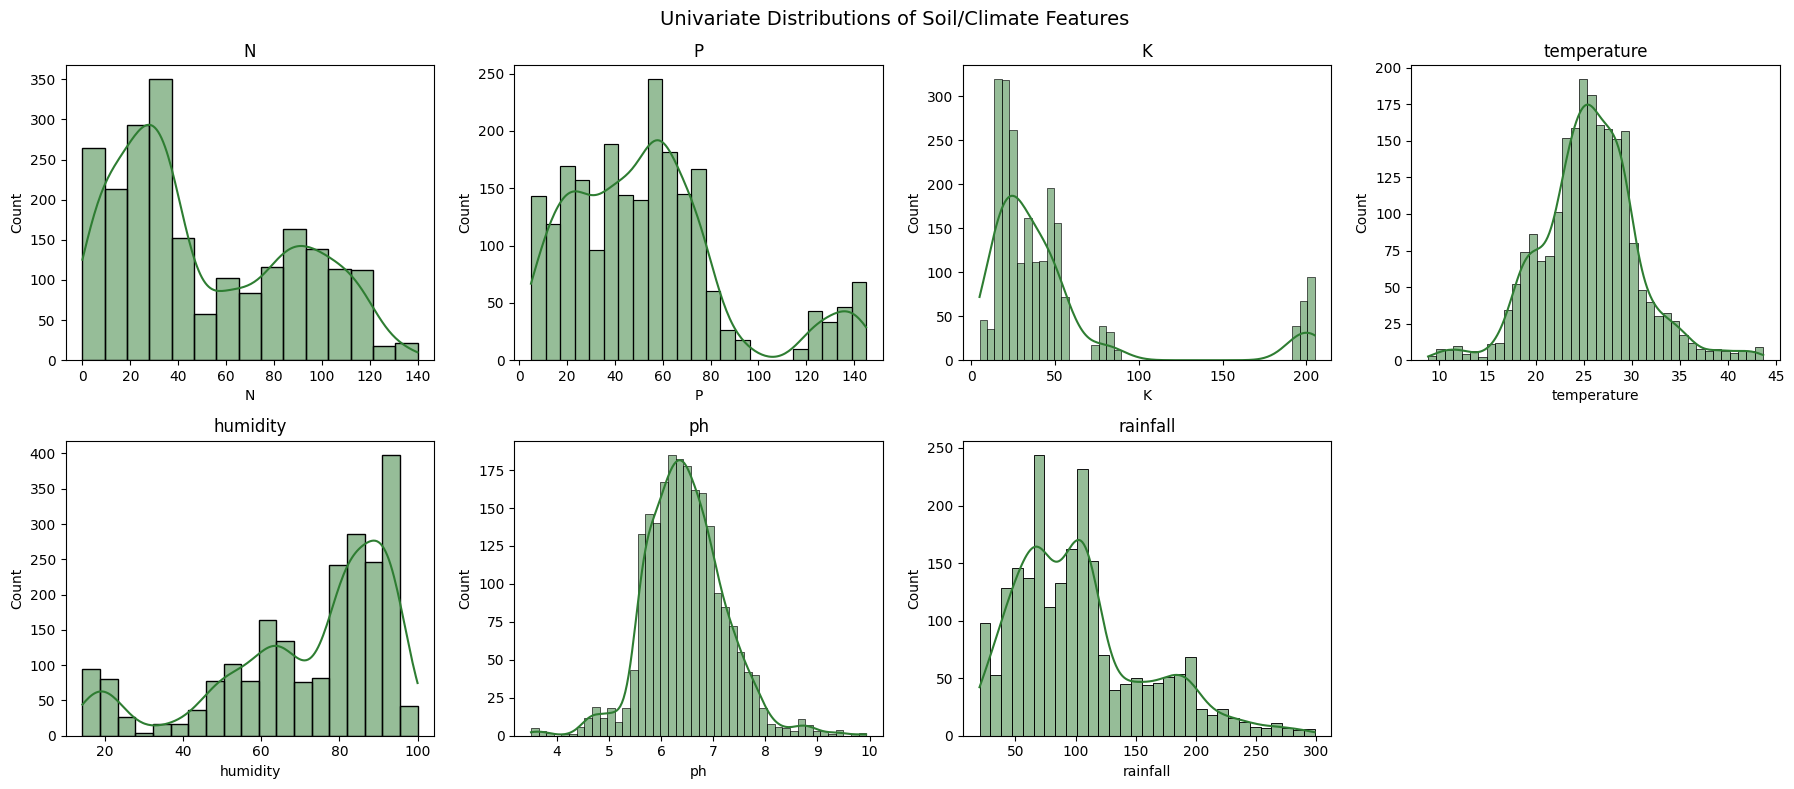

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(FEATURES):
    sns.histplot(df[col], kde=True, ax=axes[i], color="#2e7d32")
    axes[i].set_title(col)
axes[-1].axis("off")  # 8th subplot unused (7 features only)
plt.suptitle("Univariate Distributions of Soil/Climate Features", fontsize=14)
plt.tight_layout()
plt.show()

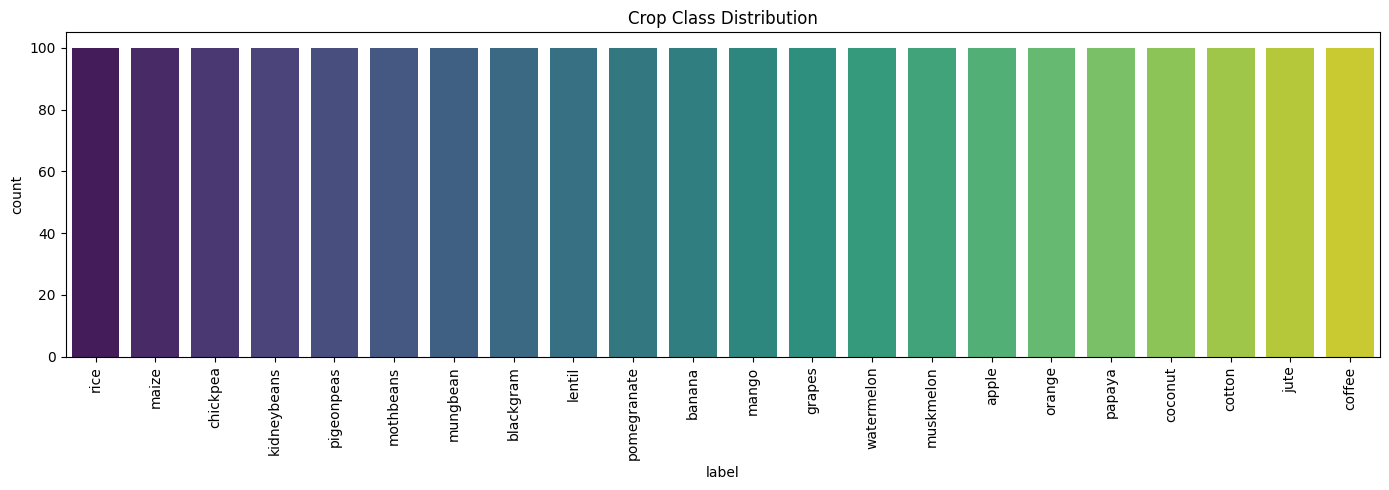

In [ ]:
plt.figure(figsize=(14, 5))
sns.countplot(data=df, x="label", order=df["label"].value_counts().index, palette="viridis")
plt.xticks(rotation=90)
plt.title("Crop Class Distribution")
plt.tight_layout()
plt.show()

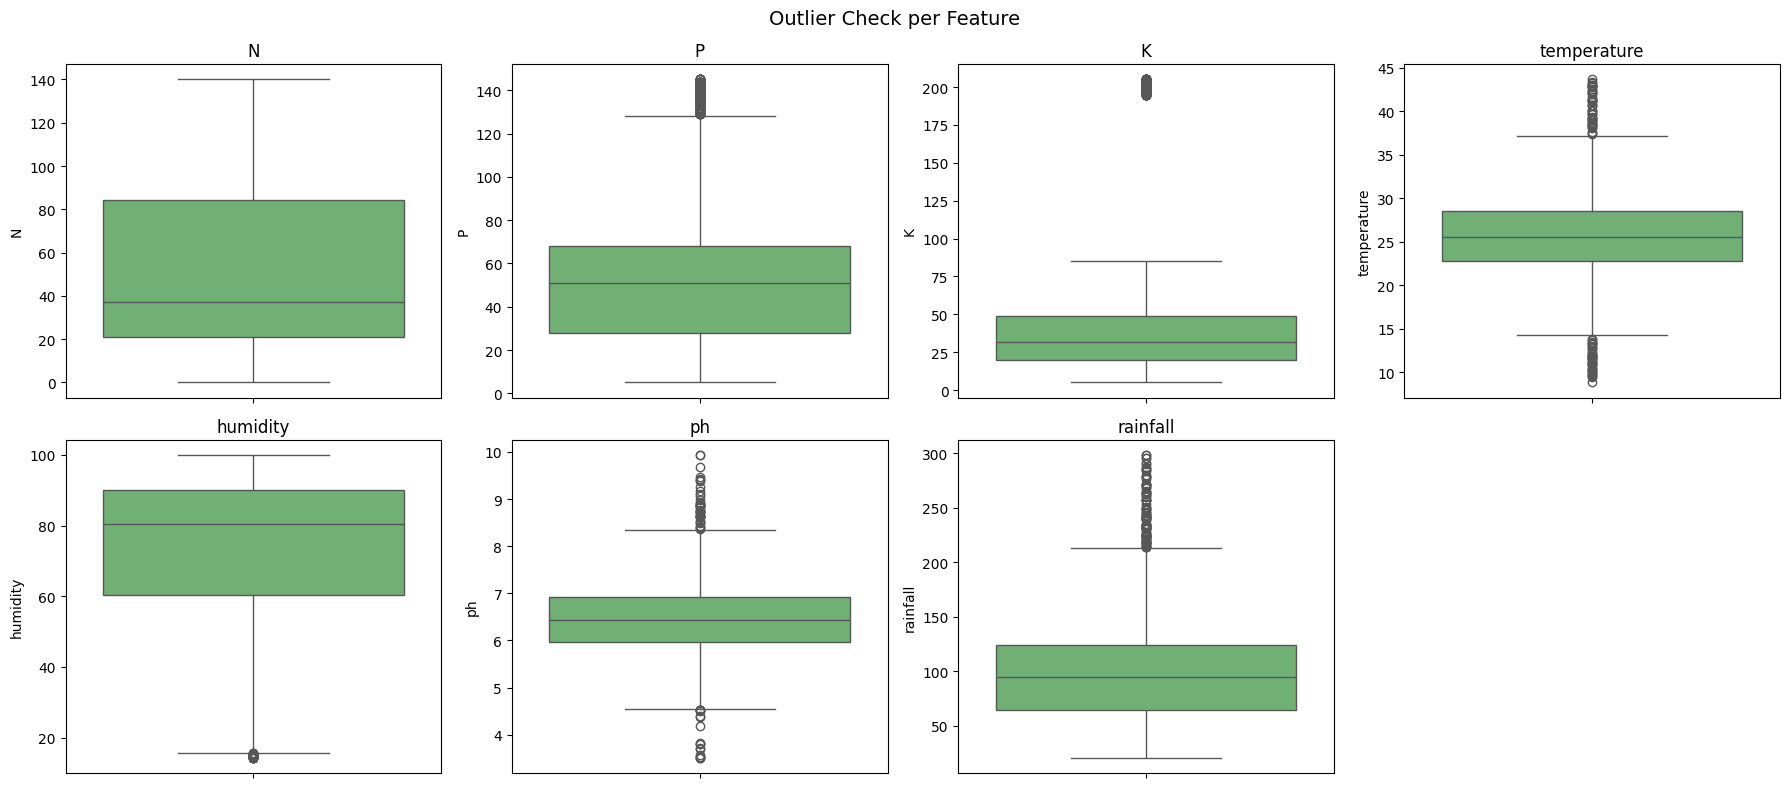

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(FEATURES):
    sns.boxplot(y=df[col], ax=axes[i], color="#66bb6a")
    axes[i].set_title(col)
axes[-1].axis("off")
plt.suptitle("Outlier Check per Feature", fontsize=14)
plt.tight_layout()
plt.show()

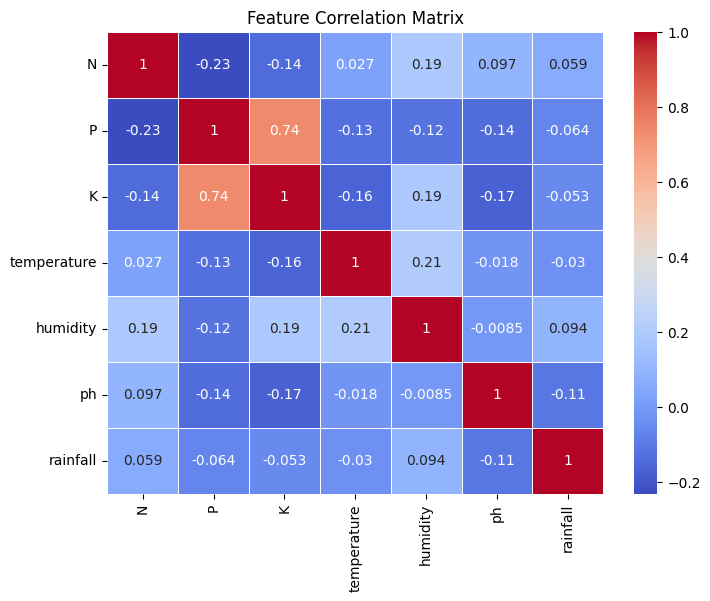

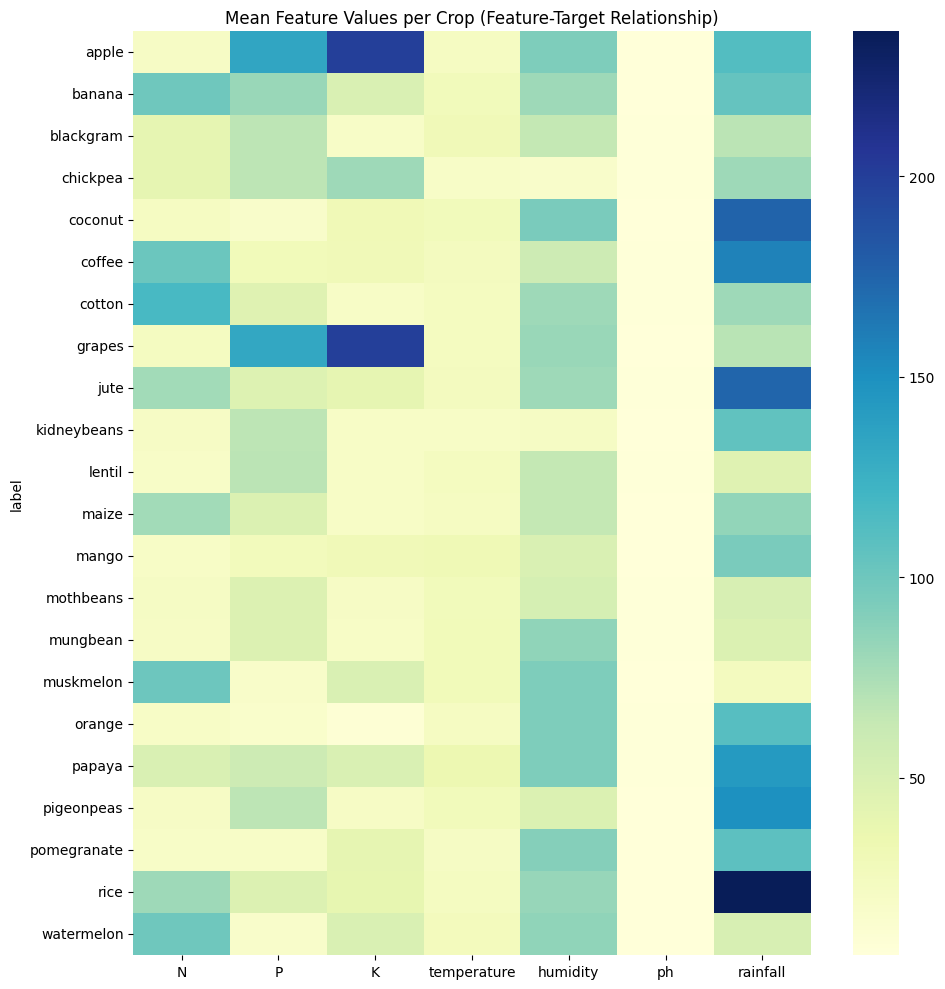

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[FEATURES].corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()

crop_means = df.groupby("label")[FEATURES].mean()
plt.figure(figsize=(10, 10))
sns.heatmap(crop_means, cmap="YlGnBu", annot=False)
plt.title("Mean Feature Values per Crop (Feature-Target Relationship)")
plt.tight_layout()
plt.show()

### EDA Findings Summary
- Dataset is clean: no missing values or duplicate rows found.
- All 22 crop classes are perfectly balanced (100 samples each), supporting the use
  of accuracy and macro-averaged metrics as valid primary evaluation metrics.
- [Idagdag niyo dito yung specific na nakita niyo — hal. "Rice requires notably higher
  rainfall and humidity than coffee or cotton, visible in the feature-means heatmap" —
  base sa aktwal na resulta pagka-run niyo]
- No extreme outliers that appear to be data entry errors were observed in the box plots;
  variation across crops reflects genuine agronomic differences rather than noise.
- These findings directly inform the choice to skip additional outlier removal, and
  confirm that feature scaling is only necessary for distance/gradient-based models
  (Logistic Regression), not tree-based models (Decision Tree, Random Forest).

In [ ]:
X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,            # preserves per-class balance in both splits
    random_state=RANDOM_STATE
)
print(f"Train shape: {X_train.shape} | Test shape: {X_test.shape}")
class_labels = sorted(y_train.unique())

Train shape: (1760, 7) | Test shape: (440, 7)


## 3. Build pipelines
- **Logistic Regression** gets `StandardScaler` (it's a distance/gradient-based linear model — scale matters).
- **Decision Tree** and **Random Forest** skip scaling (axis-aligned splits are scale-invariant).

In [ ]:
def build_pipelines(random_state=RANDOM_STATE):
    dt_pipeline = Pipeline([
        ("classifier", DecisionTreeClassifier(random_state=random_state))
    ])

    logreg_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(max_iter=2000, random_state=random_state))
    ])

    rf_pipeline = Pipeline([
        ("classifier", RandomForestClassifier(random_state=random_state))
    ])

    return {
        "Decision Tree": dt_pipeline,
        "Logistic Regression": logreg_pipeline,
        "Random Forest": rf_pipeline,
    }

pipelines = build_pipelines()

## 4. Baseline models (default hyperparameters)

In [ ]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test, cv_folds=5):
    y_pred = model.predict(X_test)

    test_accuracy = accuracy_score(y_test, y_pred)
    macro_precision = precision_score(y_test, y_pred, average="macro")
    macro_recall = recall_score(y_test, y_pred, average="macro")
    macro_f1 = f1_score(y_test, y_pred, average="macro")

    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)

    print(f"\n{'='*60}\n{name} — Test Set Performance\n{'='*60}")
    print(f"Accuracy:          {test_accuracy:.4f}")
    print(f"Macro Precision:   {macro_precision:.4f}")
    print(f"Macro Recall:      {macro_recall:.4f}")
    print(f"Macro F1-Score:    {macro_f1:.4f}")
    print(f"5-Fold CV Macro-F1: mean={cv_scores.mean():.4f}, std={cv_scores.std():.4f}")
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred, zero_division=0))

    return {
        "model": name, "test_accuracy": test_accuracy,
        "macro_precision": macro_precision, "macro_recall": macro_recall,
        "macro_f1": macro_f1, "cv_f1_mean": cv_scores.mean(),
        "cv_f1_std": cv_scores.std(), "y_pred": y_pred,
    }

baseline_results = {}
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    baseline_results[name] = evaluate_model(f"{name} (Baseline)", pipe, X_train, y_train, X_test, y_test)


Decision Tree (Baseline) — Test Set Performance
Accuracy:          0.9795
Macro Precision:   0.9806
Macro Recall:      0.9795
Macro F1-Score:    0.9794
5-Fold CV Macro-F1: mean=0.9852, std=0.0068

Classification Report:

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.80      0.89        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      0.95      0.95        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.86      0.90      0.88        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.

## 5. Hyperparameter tuning with `GridSearchCV`

In [ ]:
def get_param_grids():
    dt_grid = {
        "classifier__max_depth": [5, 8, 10, 15, None],
        "classifier__min_samples_split": [2, 5, 10],
        "classifier__min_samples_leaf": [1, 2, 4],
        "classifier__criterion": ["gini", "entropy"],
    }
    rf_grid = {
        "classifier__n_estimators": [100, 200, 300],
        "classifier__max_depth": [8, 12, 16, None],
        "classifier__min_samples_split": [2, 5],
        "classifier__min_samples_leaf": [1, 2],
        "classifier__max_features": ["sqrt", "log2"],
    }
    logreg_grid = {
        "classifier__C": [0.01, 0.1, 1, 10, 100],
        "classifier__solver": ["lbfgs"],
    }
    return {"Decision Tree": dt_grid, "Random Forest": rf_grid, "Logistic Regression": logreg_grid}

def tune_model(name, pipeline, param_grid, X_train, y_train, cv_folds=5):
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)
    search = GridSearchCV(
        pipeline, param_grid=param_grid, cv=cv,
        scoring="f1_macro", n_jobs=-1, refit=True,
    )
    search.fit(X_train, y_train)
    print(f"[{name}] Best params: {search.best_params_}")
    print(f"[{name}] Best CV macro-F1 (during search): {search.best_score_:.4f}")
    return search.best_estimator_

pipelines = build_pipelines()  # fresh, unfitted pipelines
param_grids = get_param_grids()

tuned_models = {}
for name, pipe in pipelines.items():
    tuned_models[name] = tune_model(name, pipe, param_grids[name], X_train, y_train)

[Decision Tree] Best params: {'classifier__criterion': 'gini', 'classifier__max_depth': 15, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5}
[Decision Tree] Best CV macro-F1 (during search): 0.9858
[Logistic Regression] Best params: {'classifier__C': 100, 'classifier__solver': 'lbfgs'}
[Logistic Regression] Best CV macro-F1 (during search): 0.9776
[Random Forest] Best params: {'classifier__max_depth': 16, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
[Random Forest] Best CV macro-F1 (during search): 0.9960


## 6. Evaluate tuned models on the test set + confusion matrices

In [ ]:
final_results = {}
for name, model in tuned_models.items():
    final_results[name] = evaluate_model(name, model, X_train, y_train, X_test, y_test)


Decision Tree — Test Set Performance
Accuracy:          0.9818
Macro Precision:   0.9830
Macro Recall:      0.9818
Macro F1-Score:    0.9817
5-Fold CV Macro-F1: mean=0.9858, std=0.0067

Classification Report:

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.80      0.89        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.86      0.90      0.88        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.86      0.9

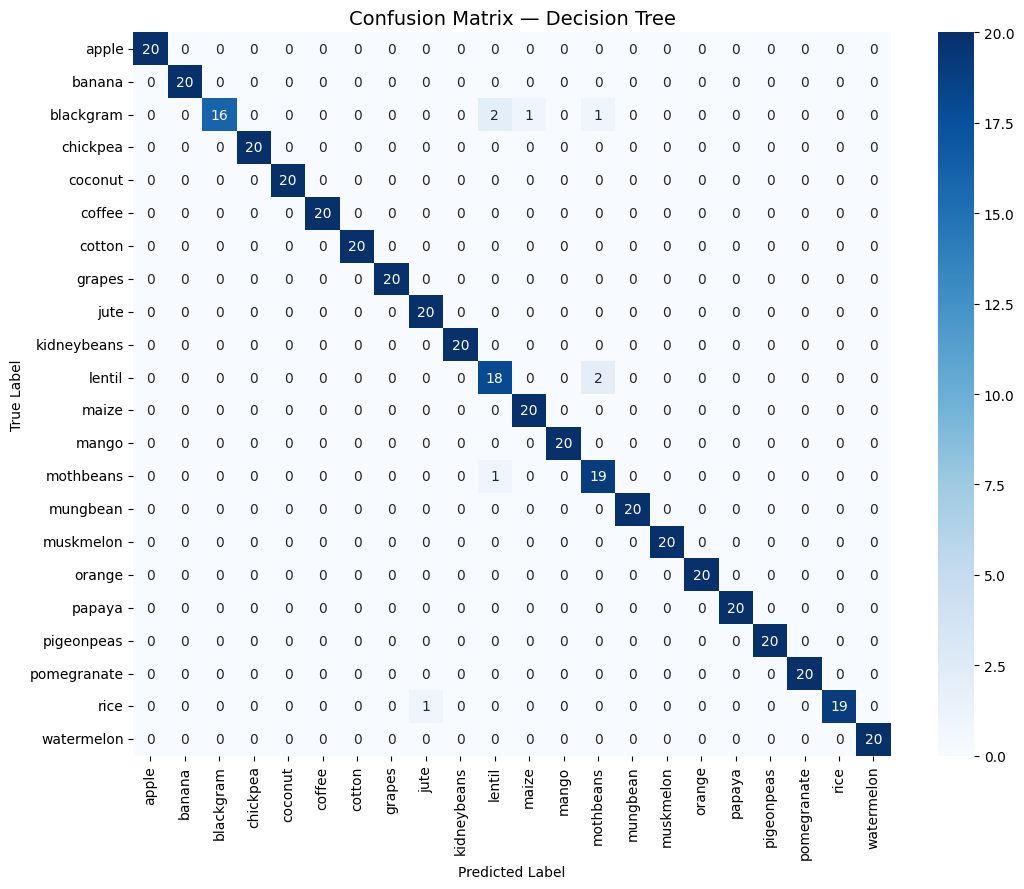

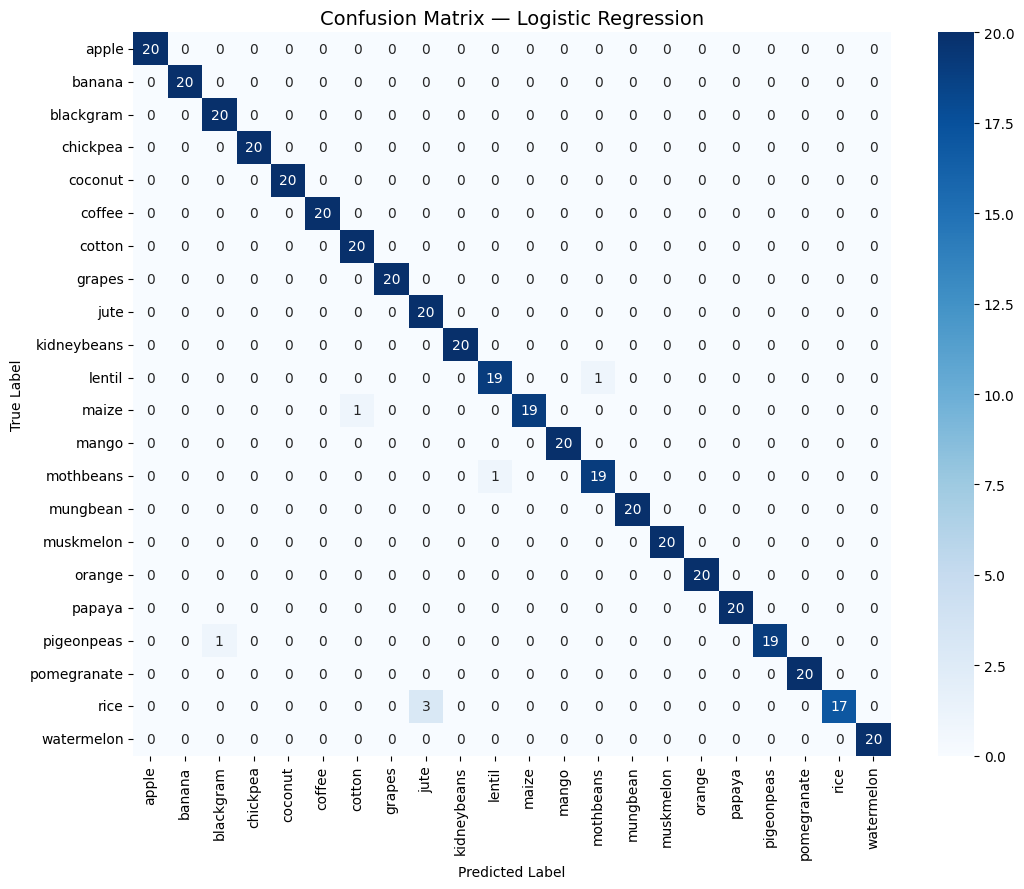

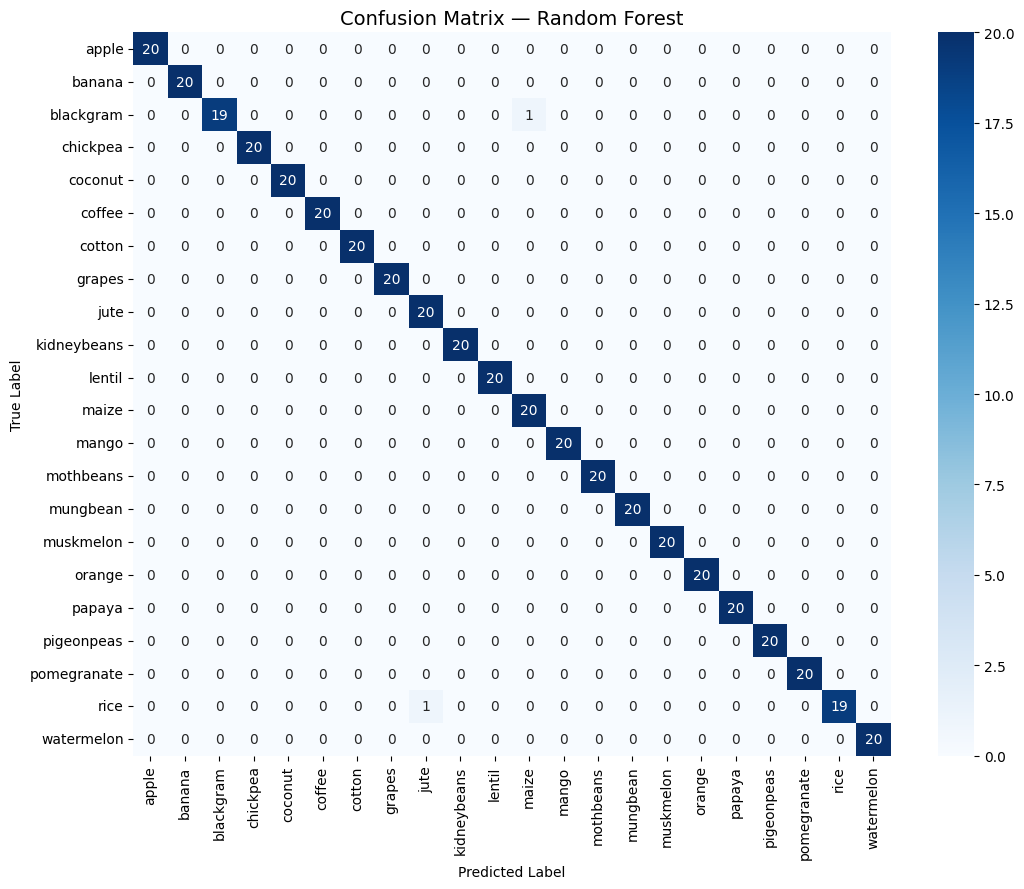

In [ ]:
def plot_confusion_matrix(name, y_test, y_pred, labels):
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    plt.figure(figsize=(11, 9))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels, cbar=True)
    plt.title(f"Confusion Matrix — {name}", fontsize=14)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

for name, model in tuned_models.items():
    plot_confusion_matrix(name, y_test, final_results[name]["y_pred"], class_labels)

## 7. Feature importance (Decision Tree, Random Forest) and coefficients (Logistic Regression)

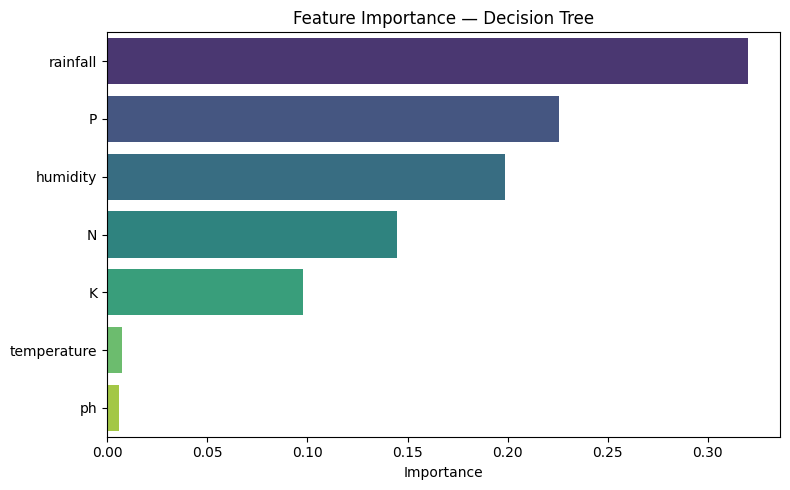

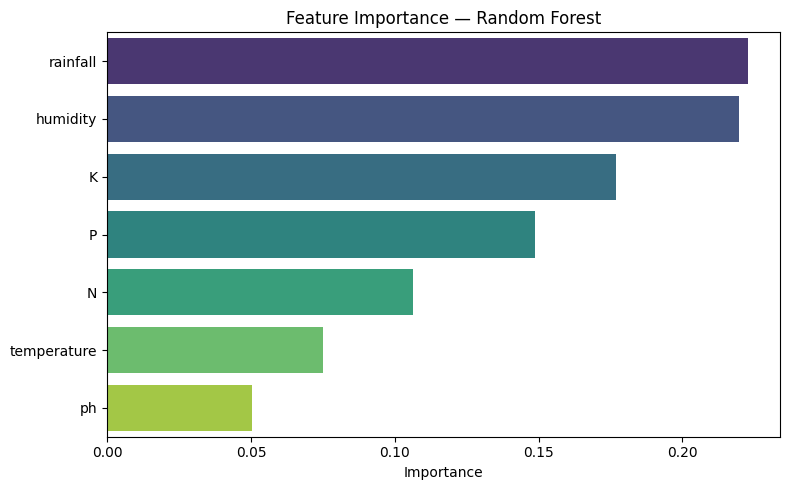

In [ ]:
def plot_tree_feature_importance(name, model, feature_names):
    importances = model.named_steps["classifier"].feature_importances_
    order = np.argsort(importances)[::-1]
    plt.figure(figsize=(8, 5))
    sns.barplot(x=importances[order], y=np.array(feature_names)[order], palette="viridis")
    plt.title(f"Feature Importance — {name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

plot_tree_feature_importance("Decision Tree", tuned_models["Decision Tree"], FEATURES)
plot_tree_feature_importance("Random Forest", tuned_models["Random Forest"], FEATURES)

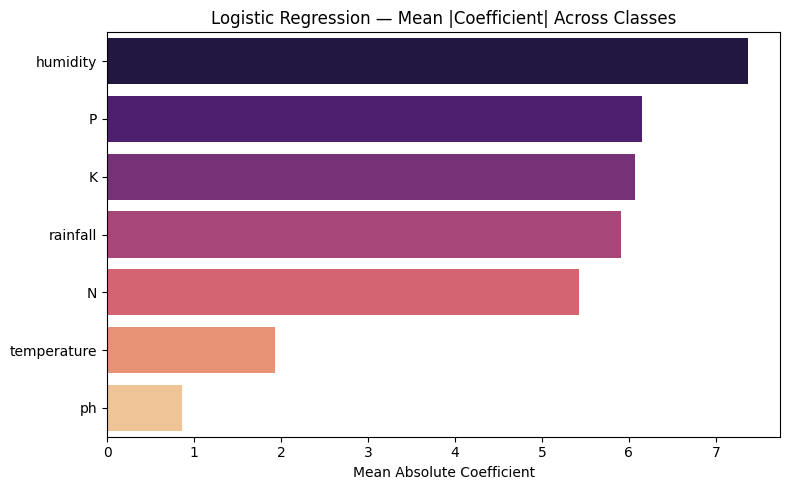

,N,P,K,temperature,humidity,ph,rainfall
apple,-2.673085,8.708345,10.694869,0.381815,7.605101,-1.777235,6.364621
banana,8.680407,9.214170,2.160163,2.943359,3.477250,-2.548128,0.718654
blackgram,-1.287653,9.104924,-2.126446,0.465679,-0.062143,0.293040,-1.835753
chickpea,-0.558739,1.790899,8.610993,-3.999874,-13.315676,1.655970,-0.102619
coconut,-6.724542,-8.540499,0.934643,2.450702,10.321342,-1.742249,9.350090
coffee,10.035620,-7.276543,-2.121981,0.238385,-11.392961,2.207177,5.597210
cotton,12.184949,3.400002,-10.351487,-2.300961,6.254446,1.457091,-1.012521
grapes,-2.557446,7.978245,11.967130,0.704589,-1.182066,-1.598272,-7.210505
jute,4.497373,0.522410,1.801860,-0.210097,2.627752,0.996318,5.428680
kidneybeans,-3.404919,2.292032,-3.836779,-1.753629,-20.472273,0.326361,5.626136


In [ ]:
def plot_logreg_coefficients(model, feature_names, class_names):
    coefs = model.named_steps["classifier"].coef_   # shape: (n_classes, n_features)
    mean_abs_coef = np.mean(np.abs(coefs), axis=0)
    order = np.argsort(mean_abs_coef)[::-1]
    plt.figure(figsize=(8, 5))
    sns.barplot(x=mean_abs_coef[order], y=np.array(feature_names)[order], palette="magma")
    plt.title("Logistic Regression — Mean |Coefficient| Across Classes")
    plt.xlabel("Mean Absolute Coefficient")
    plt.tight_layout()
    plt.show()
    return pd.DataFrame(coefs, index=class_names, columns=feature_names)

logreg_coef_df = plot_logreg_coefficients(tuned_models["Logistic Regression"], FEATURES, class_labels)
logreg_coef_df

## 8. Final model comparison table

In [ ]:
comparison_df = pd.DataFrame([
    {
        "Model": name,
        "Test Accuracy": res["test_accuracy"],
        "CV F1 Mean": res["cv_f1_mean"],
        "CV F1 Std": res["cv_f1_std"],
        "Macro F1 (Test)": res["macro_f1"],
        "Macro Precision (Test)": res["macro_precision"],
        "Macro Recall (Test)": res["macro_recall"],
    }
    for name, res in final_results.items()
]).sort_values("Macro F1 (Test)", ascending=False).reset_index(drop=True)

comparison_df

,Model,Test Accuracy,CV F1 Mean,CV F1 Std,Macro F1 (Test),Macro Precision (Test),Macro Recall (Test)
0,Random Forest,0.995455,0.996002,0.004981,0.995452,0.995671,0.995455
1,Logistic Regression,0.984091,0.977581,0.005849,0.984049,0.985197,0.984091
2,Decision Tree,0.981818,0.985815,0.006711,0.981694,0.982979,0.981818


In [ ]:
import joblib

# Automatically pick the best model based on Macro F1 (Test)
best_model_name = comparison_df.iloc[0]["Model"]
best_model = tuned_models[best_model_name]

print(f"Saving best model: {best_model_name}")

joblib.dump(best_model, "crop_recommendation_model.pkl")
joblib.dump(FEATURES, "feature_names.pkl")
joblib.dump(class_labels, "class_labels.pkl")

print("Saved: crop_recommendation_model.pkl, feature_names.pkl, class_labels.pkl")

Saving best model: Random Forest
Saved: crop_recommendation_model.pkl, feature_names.pkl, class_labels.pkl


In [ ]:
from google.colab import files
files.download("crop_recommendation_model.pkl")
files.download("feature_names.pkl")
files.download("class_labels.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>